<a href="https://colab.research.google.com/github/KadeejaHibaPT/AI-Chatbot-Frontend/blob/main/AML_lab_exp2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Lambda     | w          | b          | Train MSE    | Test MSE  
--------------------------------------------------------------
0          | 1.8500     | 0.3571     | 0.1410       | 0.6384    
0.01       | 1.8454     | 0.3756     | 0.1411       | 0.6651    
0.1        | 1.8049     | 0.5376     | 0.1492       | 0.9461    
1          | 1.4800     | 1.8371     | 0.6886       | 6.2471    
10         | 0.5286     | 5.6429     | 7.1257       | 52.9386   
100        | 0.0712     | 7.4725     | 12.7982      | 91.9269   
--------------------------------------------------------------
Optimal Lambda with Minimum Testing Error: 0 (Test MSE = 0.6384)



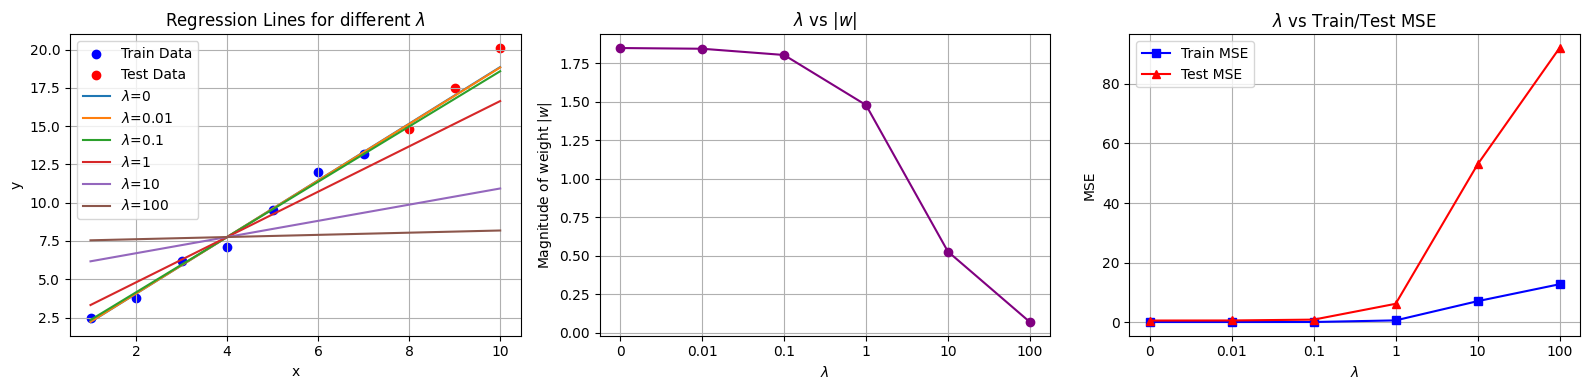

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

# 1. Dataset (10 points)
x = np.array([1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0])
y = np.array([2.5, 3.8, 6.2, 7.1, 9.5, 12.0, 13.2, 14.8, 17.5, 20.1])

# 2. Split into Training (first 7) and Testing (last 3)
x_train, y_train = x[:7], y[:7]
x_test, y_test = x[7:], y[7:]

# 3. Define Objective Function and MSE
def regularized_loss(params, x_data, y_data, lmbda):
    w, b = params
    y_pred = w * x_data + b
    mse = np.mean((y_data - y_pred) ** 2)
    return mse + lmbda * (w ** 2)

def compute_mse(w, b, x_data, y_data):
    y_pred = w * x_data + b
    return np.mean((y_data - y_pred) ** 2)

# 4. Regularization values
lambdas = [0, 0.01, 0.1, 1, 10, 100]

results = []

# 5. Optimize parameters for each lambda
for lmbda in lambdas:
    init_params = [0.0, 0.0]  # initial [w, b]
    res = minimize(regularized_loss, init_params, args=(x_train, y_train, lmbda))

    w_opt, b_opt = res.x
    train_mse = compute_mse(w_opt, b_opt, x_train, y_train)
    test_mse = compute_mse(w_opt, b_opt, x_test, y_test)

    results.append({
        'lambda': lmbda,
        'w': w_opt,
        'b': b_opt,
        'train_mse': train_mse,
        'test_mse': test_mse
    })

# 6. Display Summary Table
print(f"{'Lambda':<10} | {'w':<10} | {'b':<10} | {'Train MSE':<12} | {'Test MSE':<10}")
print("-" * 62)
best_lambda = None
min_test_mse = float('inf')

for r in results:
    print(f"{r['lambda']:<10} | {r['w']:<10.4f} | {r['b']:<10.4f} | {r['train_mse']:<12.4f} | {r['test_mse']:<10.4f}")
    if r['test_mse'] < min_test_mse:
        min_test_mse = r['test_mse']
        best_lambda = r['lambda']

print("-" * 62)
print(f"Optimal Lambda with Minimum Testing Error: {best_lambda} (Test MSE = {min_test_mse:.4f})\n")

# 7. Visualization Plots
plt.figure(figsize=(16, 4))

# Plot 1: Fitted Regression Lines
plt.subplot(1, 3, 1)
plt.scatter(x_train, y_train, color='blue', label='Train Data')
plt.scatter(x_test, y_test, color='red', label='Test Data')
x_vals = np.linspace(min(x), max(x), 100)

for r in results:
    y_vals = r['w'] * x_vals + r['b']
    plt.plot(x_vals, y_vals, label=fr"$\lambda$={r['lambda']}")

plt.title(r"Regression Lines for different $\lambda$")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(True)

# Plot 2: Lambda vs |w|
plt.subplot(1, 3, 2)
w_mags = [abs(r['w']) for r in results]
plt.plot([str(l) for l in lambdas], w_mags, marker='o', color='purple')
plt.title(r"$\lambda$ vs $|w|$")
plt.xlabel(r"$\lambda$")
plt.ylabel("Magnitude of weight $|w|$")
plt.grid(True)

# Plot 3: Lambda vs Errors
plt.subplot(1, 3, 3)
train_mses = [r['train_mse'] for r in results]
test_mses = [r['test_mse'] for r in results]
plt.plot([str(l) for l in lambdas], train_mses, marker='s', label='Train MSE', color='blue')
plt.plot([str(l) for l in lambdas], test_mses, marker='^', label='Test MSE', color='red')
plt.title(r"$\lambda$ vs Train/Test MSE")
plt.xlabel(r"$\lambda$")
plt.ylabel("MSE")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()